# 03 · Correcció del radar amb les estacions

El notebook 01 mostra que el biaix del radar **canvia molt d'un lloc a un altre** i d'un dia a un altre. Una taula de colors única (notebook 02) no ho pot corregir. Aquí provem correccions que fan servir les estacions XEMA de cada dia, que és l'estàndard operatiu (*radar–gauge merging*):

| Mètode | Idea |
|---|---|
| **Biaix mitjà diari** (*mean field bias*) | Cada dia, un sol factor per a tot Catalunya: Σ XEMA / Σ radar a les estacions on plou. |
| **Correcció local diària** | Cada dia, el quocient XEMA/radar a cada estació s'interpola (IDW, dins de 30 km) i s'aplica al radar. On no hi ha cap estació a prop, es fa servir el biaix mitjà. |
| **Factor estàtic** | Un factor fix per lloc, calculat amb tot el període (com un mapa climatològic del biaix del radar). No necessita dades del dia. |

Ho provem sobre la taula original i sobre la taula ajustada amb el model potència (notebook 02).

**Validació *leave-one-out*:** cada estació es corregeix **sense fer servir la seva pròpia dada**, només amb les veïnes. És exactament la situació d'un punt del mapa on no hi ha estació. En el cas de la taula ajustada, a més, l'estació avaluada tampoc no ha participat en l'ajust de la taula (validació creuada del notebook 02).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import calibracio as C
C.estil()
pd.set_option('display.precision', 2); pd.set_option('display.width', 200)

In [2]:
df = C.control_qualitat(C.carregar())
df['original'] = C.radar_amb_taula(df, C.CLASSES, normalitzar=False)
df['ajustada'], _ = C.ajust_cv(df, 'potencia')
for base in ['original', 'ajustada']:
    df[f'{base} + biaix mitjà'] = C.correccio_mfb(df, base)
    df[f'{base} + local'] = C.correccio_local(df, base)
    df[f'{base} + estàtic'] = df[base] * df.codi.map(C.factor_estatic_loo(df, base))
q = df[df.qc_ok]
metodes = ['original', 'original + estàtic', 'original + biaix mitjà', 'original + local',
           'ajustada', 'ajustada + estàtic', 'ajustada + biaix mitjà', 'ajustada + local']
M = C.taula_metriques(q, metodes)
M

,n,ratio_total,r,MAE,RMSE,biaix_mitja,falses_alarmes_%,no_detectada_%
original,5044.0,0.46,0.51,6.87,13.21,-5.57,0.95,11.10
original + estàtic,5044.0,0.92,0.56,6.56,12.15,-0.85,2.27,5.91
original + biaix mitjà,5044.0,0.94,0.66,5.85,10.78,-0.65,1.36,5.80
original + local,5044.0,0.91,0.72,4.94,10.28,-0.92,1.19,4.69
ajustada,5044.0,0.94,0.61,5.97,10.95,-0.66,4.80,3.22
ajustada + estàtic,5044.0,0.96,0.65,5.84,10.58,-0.46,4.72,3.12
ajustada + biaix mitjà,5044.0,0.95,0.67,5.51,10.25,-0.48,3.98,3.04
ajustada + local,5044.0,0.89,0.79,4.32,8.57,-1.15,3.45,3.12


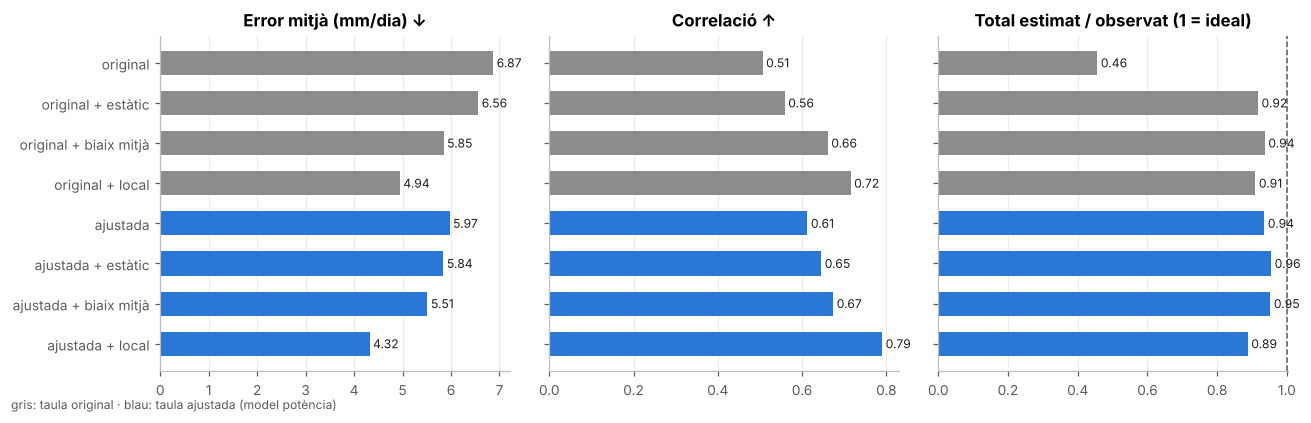

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
y = np.arange(len(metodes))[::-1]
cols = [C.COLORS['gris'] if m.startswith('original') else C.COLORS['blau'] for m in metodes]
for ax, (k, titol, ref) in zip(axs, [('MAE', 'Error mitjà (mm/dia) ↓', None), ('r', 'Correlació ↑', None),
                                     ('ratio_total', 'Total estimat / observat (1 = ideal)', 1)]):
    ax.barh(y, M[k], color=cols, height=.6)
    for yi, v in zip(y, M[k]):
        ax.text(v, yi, f" {v:.2f}", va='center', fontsize=8, color=C.COLORS['tinta'])
    if ref: ax.axvline(ref, color=C.COLORS['tinta2'], lw=1, ls='--')
    ax.set_title(titol); ax.grid(axis='y', visible=False)
axs[0].set_yticks(y, metodes)
fig.text(.01, .01, 'gris: taula original · blau: taula ajustada (model potència)', color=C.COLORS['tinta2'], fontsize=8)
plt.tight_layout(); plt.show()

## Sensibilitat al radi de la correcció local

In [4]:
rows = []
for radi in [10, 20, 30, 50, 80]:
    est = C.correccio_local(df, 'ajustada', radi_km=radi)
    m = C.metriques(df.obs[df.qc_ok], est[df.qc_ok.to_numpy()])
    rows.append({'radi_km': radi, **m[['r', 'MAE', 'RMSE', 'ratio_total']].to_dict()})
pd.DataFrame(rows).set_index('radi_km')

,r,MAE,RMSE,ratio_total
radi_km,,,,
10,0.72,5.03,10.00,0.96
20,0.78,4.53,8.89,0.93
30,0.79,4.32,8.57,0.89
50,0.79,4.30,8.60,0.86
80,0.79,4.33,8.73,0.84


## Com queda el millor mètode

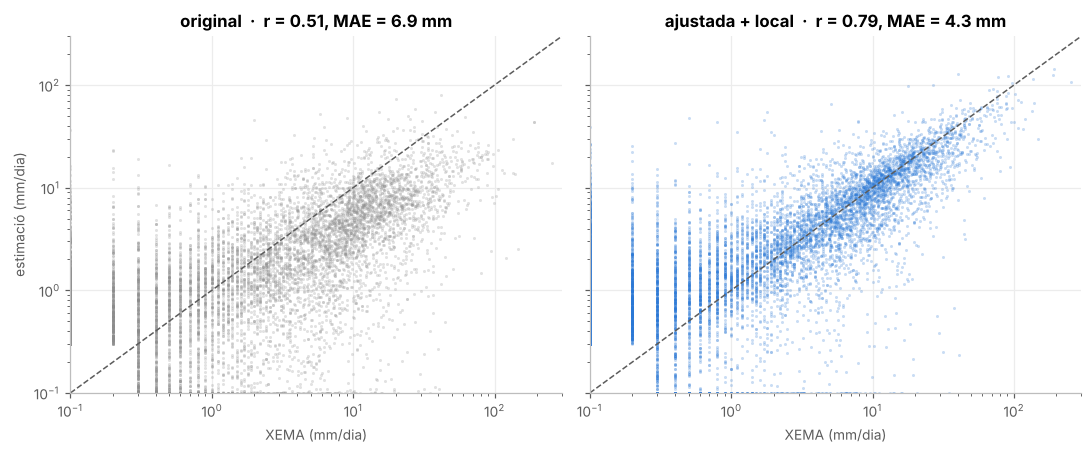

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)
for ax, col, color in [(axs[0], 'original', C.COLORS['gris']), (axs[1], 'ajustada + local', C.COLORS['blau'])]:
    w = q[(q.obs >= .2) | (q[col] >= .2)]
    ax.scatter(w.obs + .1, w[col] + .1, s=4, alpha=.25, color=color, linewidths=0)
    ax.plot([.1, 300], [.1, 300], color=C.COLORS['tinta2'], lw=1, ls='--')
    m = C.metriques(q.obs, q[col])
    ax.set(xscale='log', yscale='log', xlim=(.1, 300), ylim=(.1, 300), xlabel='XEMA (mm/dia)',
           title=f"{col}  ·  r = {m.r:.2f}, MAE = {m.MAE:.1f} mm")
axs[0].set_ylabel('estimació (mm/dia)')
plt.tight_layout(); plt.show()

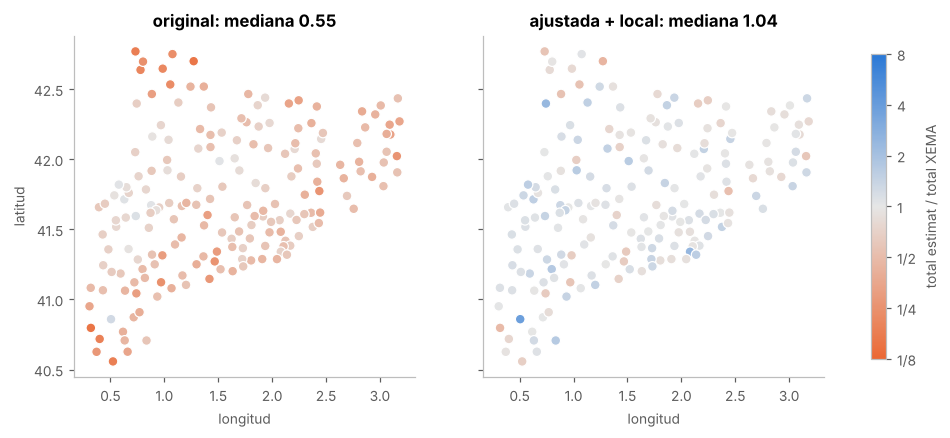

In [6]:
# Biaix per estació (total del període) abans i després
st = C.estacions(df)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
for ax, col in zip(axs, ['original', 'ajustada + local']):
    s = q.groupby('codi').agg(o=('obs', 'sum'), r=(col, 'sum')).join(st)
    sc = ax.scatter(s.lon, s.lat, c=np.log2(s.r / s.o), cmap=C.cmap_divergent(), vmin=-3, vmax=3, s=40,
                    edgecolors='white', linewidths=.8)
    ax.set(title=f"{col}: mediana {np.median(s.r / s.o):.2f}", xlabel='longitud'); ax.set_aspect(1.3); ax.grid(False)
axs[0].set_ylabel('latitud')
cb = fig.colorbar(sc, ax=axs, shrink=.75, ticks=[-3, -2, -1, 0, 1, 2, 3])
cb.ax.set_yticklabels(['1/8', '1/4', '1/2', '1', '2', '4', '8']); cb.set_label('total estimat / total XEMA')
plt.show()

In [7]:
# Acumulats mensuals per estació: error relatiu
r = []
for col in ['original', 'ajustada', 'ajustada + local']:
    m = q.assign(mes=q.data.dt.to_period('M')).groupby(['codi', 'mes']).agg(o=('obs', 'sum'), e=(col, 'sum'))
    m = m[m.o >= 10]
    r.append({'mètode': col, 'mediana estimat/observat': np.median(m.e / m.o),
              '% mesos dins ±25%': 100 * ((m.e / m.o).between(.75, 1.25)).mean(),
              'MAE mensual (mm)': (m.e - m.o).abs().mean()})
pd.DataFrame(r).set_index('mètode')

,mediana estimat/observat,% mesos dins ±25%,MAE mensual (mm)
mètode,,,
original,0.51,18.87,28.92
ajustada,1.21,32.36,23.10
ajustada + local,0.99,51.52,15.35


## Conclusions

- **La correcció local diària amb les estacions és la millora més gran**, més que reajustar la taula. Combinant-les (taula ajustada + correcció local) s'obté el millor resultat en llocs **sense estació** (validació *leave-one-out*): la correlació passa de ~0,51 a ~0,79 i l'error mitjà baixa aproximadament un 35%.
- El biaix mitjà diari (un sol factor per a tot Catalunya) també millora força, però menys que la correcció local, perquè no pot corregir les diferències entre zones.
- El factor estàtic és el que menys aporta: el biaix del radar canvia molt d'un episodi a un altre.
- Un radi d'uns 30 km per a la correcció local és un bon compromís.
- Els acumulats mensuals per estació que queden dins de ±25% de l'observat passen del ~19% al ~51%.
- **Limitacions:** una correcció multiplicativa no pot crear pluja on el radar marca 0 (la pluja no detectada només millora gràcies a la taula ajustada), i encara queda una subestimació global d'un ~10%.

### Proposta per al pipeline (encara no aplicada)
1. Aplicar la taula del model potència (`resultats/taula_colors_proposada.json`) i normalitzar per les imatges descarregades.
2. A l'acumulat diari, aplicar la correcció local amb les estacions XEMA del mateix dia (radi 30 km, mean field bias on no hi hagi estacions).
3. Setmanals i mensuals: sumar els diaris corregits. Caldrà revisar si la validació d'"anticicló" continua sent útil: la correcció tal com està programada no toca els dies en què cap estació registra pluja.